## Bedrock facts

1. An image is a 2D array of intensity values (grayscale: one channel)
2. Spatial filtering computes each output pixel as a function of its neighbours.
3. Most filters are implemented as convolution with a kernel (mask).
4. Filters fall into:
  - Averaging (smoothing)
  - Linear edge detectors
  - Non-linear filters
  - Gaussian filters

5. Kernel size controls scale:
  - small kernel: preserves details
  - large kernel: stronger smoothing, loss of line structure



### Step 1: Loading and Understanding a Grayscale Image

In [1]:
!pip install opencv-python numpy matplotlib

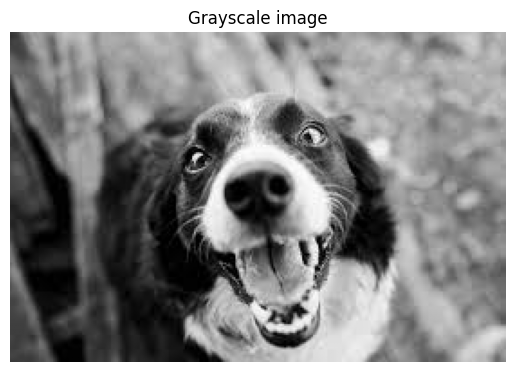

In [51]:
# load and display the image

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("test.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found, check the file path.")


# display
plt.imshow(img, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

In [52]:
# verify that image is just numbers

print("Shape: ", img.shape)
print("Data type: ", img.dtype)

Shape:  (183, 275)
Data type:  uint8


In [53]:
# look at pixel values directly

print(img[100, 100])
print(img[100, 101])
print(img[100, 102])

72
52
46


In [54]:
# visual intuition: zoom into patch

small_patch = img[100:110, 100:110]
print(small_patch)

[[ 72  52  46  47 101  83 117 184 224 240]
 [ 35  15  23  40 106 131 181 215 220 229]
 [ 18  45 107 151 202 190 194 212 229 239]
 [ 49 113 162 165 128 135 175 227 243 229]
 [121 103  52  87  67 127 179 222 236 233]
 [ 55  33  59  79  76 115 156 211 236 225]
 [ 28  22  52  65  55 133 189 218 231 230]
 [ 45  32  39  18 129 171 179 176 206 238]
 [ 30  17  25 109 151 154 154 163 193 218]
 [ 17  21  83 142 109 131 166 177 186 209]]


### Step 2: Average Filtering

#### Bedrock facts:
1. Noise appears as random intensity variations.
2. True image structures (edges, objects) are spatially correlated.
3. Averaging nearby pixels:
  - cancels random noise
  - but also reduces sharp transitions

So smoothing is a statistical operation where random terms average out, structured signals survive.


#### Box filter/Average filter:

Take all pixels in a window and give them equal importance.

![](https://i.imgur.com/j1ptusa.png)

#### Convolution

Algorithmically,
- Center kernel on pixel (x,y)
- Multiply kernel values with image values
- Sum all products
- Assign result to output pixel


In [55]:
# implement box filter manually

import numpy as np

def box_filter_manual(img: np.ndarray, k: int) -> np.ndarray:
    """
    Apply a box (averaging) filter to a grayscale image using manual convolution.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image of shape (H, W).
    k : int
        Kernel size (must be odd, e.g., 3, 5, 7).

    Returns
    -------
    filtered_img : np.ndarray
        Smoothed image after box filtering.
    """
    if k % 2 == 0:
      raise ValueError("Kernel size k must be odd")

    k = int(k)
    pad = k // 2
    h, w = img.shape

    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img, dtype=np.float32)


    for i in range(h):
      for j in range(w):
        window = padded[i:j+k, j:j+k]
        output[i,j] = np.mean(window)

    return output.astype(np.uint8)

In [56]:
box3_manual = box_filter_manual(img, 3)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-759946029.py:37: RuntimeWarning: invalid value encountered in cast
  return output.astype(np.uint8)


In [57]:
# optimised version using opencv

import cv2
import numpy as np

def box_filter_cv(img: np.ndarray, k: int) -> np.ndarray:
    """
    Apply a box (averaging) filter to a grayscale image using OpenCV.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image of shape (H, W).
    k : int
        Kernel size (must be odd, e.g., 3, 5, 7).

    Returns
    -------
    filtered_img : np.ndarray
        Smoothed image after box filtering.
    """
    if k % 2 == 0:
        raise ValueError("Kernel size k must be odd.")

    return cv2.blur(img, (k, k))

In [58]:
# experiment with different kernel size

box3 = box_filter_cv(img, 3)
box7 = box_filter_cv(img, 7)
box15 = box_filter_cv(img, 15)

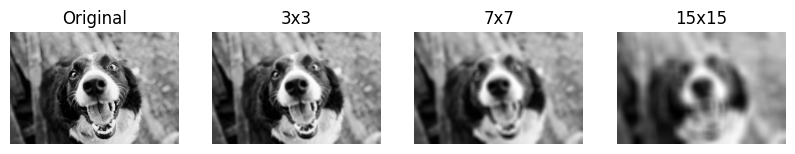

In [59]:
# compare the boxes

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i, (im, t) in enumerate([
    (img, "Original"),
    (box3, "3x3"),
    (box7, "7x7"),
    (box15, "15x15")
]):
    plt.subplot(1,4,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")

plt.show()

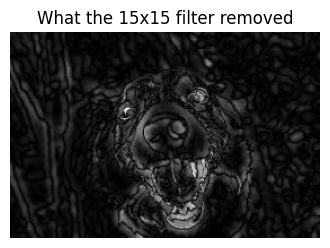

In [60]:
diff_15 = cv2.absdiff(img, box15)

plt.figure(figsize=(4,4))
plt.imshow(diff_15, cmap="gray")
plt.title("What the 15x15 filter removed")
plt.axis("off")
plt.show()

In [61]:
# let's add some gaussain noise

noise = np.random.normal(0, 20, img.shape).astype(np.int16)
noisy_img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

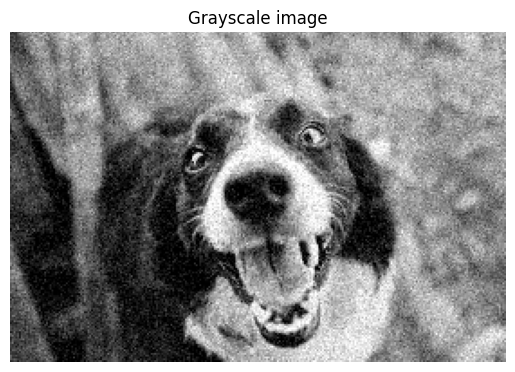

In [62]:
plt.imshow(noisy_img, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

In [63]:
# apply box filters

noisy_box3 = box_filter_cv(noisy_img, 3)
noisy_box7 = box_filter_cv(noisy_img, 7)
noisy_box15 = box_filter_cv(noisy_img, 15)

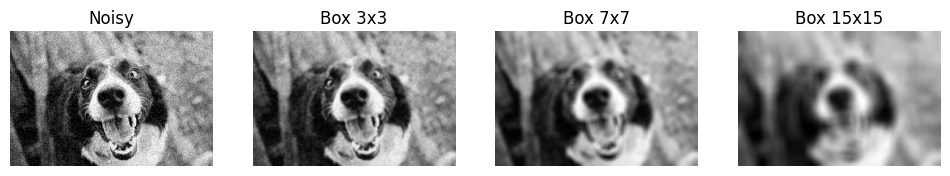

In [64]:
# visualise

plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([
    (noisy_img, "Noisy"),
    (noisy_box3, "Box 3x3"),
    (noisy_box7, "Box 7x7"),
    (noisy_box15, "Box 15x15")
]):
    plt.subplot(1,4,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")

plt.show()

#### Step 3: Gaussian Filter

In box filer, the assumption of uniform weights is false.

We need distance-based weighting.

We want weights that:
1. Are highest at the center.
2. Decrease smoothly with distance.
3. Are symmetric.

In [65]:
# gaussian filter usig opencv

import cv2
import numpy as np

def gaussian_filter(img: np.ndarray, k: int, sigma: float) -> np.ndarray:
    """
    Apply Gaussian smoothing to a grayscale image.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image of shape (H, W).
    k : int
        Kernel size (must be odd).
    sigma : float
        Standard deviation of Gaussian kernel.

    Returns
    -------
    filtered_img : np.ndarray
        Smoothed image after Gaussian filtering.
    """
    if k % 2 == 0:
        raise ValueError("Kernel size must be odd.")

    return cv2.GaussianBlur(img, (k, k), sigmaX=sigma)

In [66]:
# add noise

noise = np.random.normal(0, 20, img.shape).astype(np.int16)
noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

In [67]:
# apply gaussian filters

g1 = gaussian_filter(noisy, 5, 1)
g3 = gaussian_filter(noisy, 11, 3)
g5 = gaussian_filter(noisy, 21, 5)

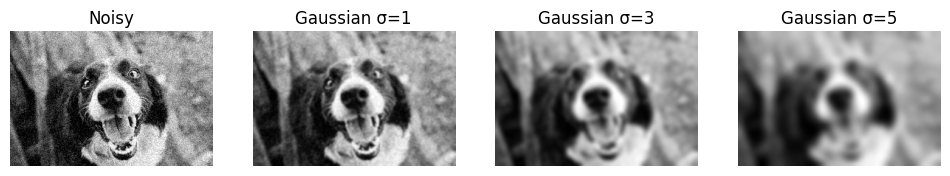

In [68]:
# display

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([
    (noisy, "Noisy"),
    (g1, "Gaussian σ=1"),
    (g3, "Gaussian σ=3"),
    (g5, "Gaussian σ=5")
]):
    plt.subplot(1,4,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")

plt.show()

In [69]:
# apply box filter

b11 = box_filter_cv(noisy, 11)

In [70]:
g15 = gaussian_filter(noisy, 21, 15)

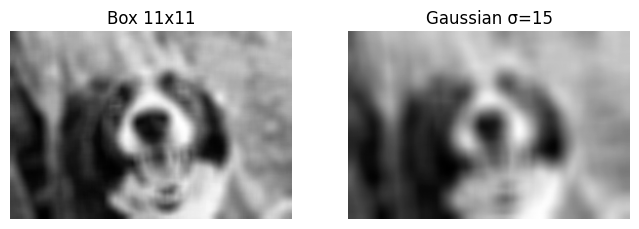

In [71]:
# compare

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(b11, cmap="gray")
plt.title("Box 11x11")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(g15, cmap="gray")
plt.title("Gaussian σ=15")
plt.axis("off")

plt.show()

#### Step 4: Linear Edge Detection Filters (Sobel, Prewitt, Laplacian)

In [72]:
# sobel filter

import cv2
import numpy as np

def sobel_edges(img: np.ndarray) -> np.ndarray:
    """
    Compute edge magnitude using Sobel operator.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.

    Returns
    -------
    edges : np.ndarray
        Gradient magnitude image highlighting edges.
    """
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    mag = cv2.magnitude(gx, gy)
    mag = np.clip(mag, 0, 255).astype(np.uint8)

    return mag

In [73]:
# prewitt filter

def prewitt_edges(img: np.ndarray) -> np.ndarray:
    """
    Compute edge magnitude using Prewitt operator.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.

    Returns
    -------
    edges : np.ndarray
        Gradient magnitude image highlighting edges.
    """
    kx = np.array([[-1, 0, 1],
                   [-1, 0, 1],
                   [-1, 0, 1]], dtype=np.float32)

    ky = np.array([[1, 1, 1],
                   [0, 0, 0],
                   [-1, -1, -1]], dtype=np.float32)

    gx = cv2.filter2D(img, -1, kx)
    gy = cv2.filter2D(img, -1, ky)

    mag = cv2.magnitude(gx.astype(np.float32), gy.astype(np.float32))
    mag = np.clip(mag, 0, 255).astype(np.uint8)

    return mag

In [74]:
# laplacian filter

def laplacian_edges(img: np.ndarray) -> np.ndarray:
    """
    Detect edges using Laplacian operator.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.

    Returns
    -------
    edges : np.ndarray
        Image highlighting second-derivative edges.
    """
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = np.clip(np.abs(lap), 0, 255).astype(np.uint8)
    return lap

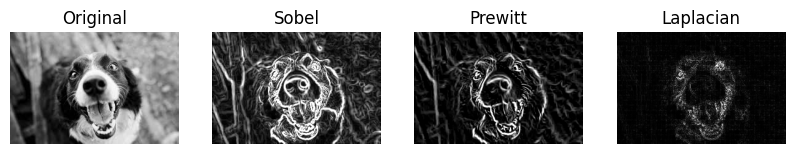

In [75]:
# visualise

sobel = sobel_edges(img)
prewitt = prewitt_edges(img)
lap = laplacian_edges(img)

plt.figure(figsize=(10,4))
for i, (im, t) in enumerate([
    (img, "Original"),
    (sobel, "Sobel"),
    (prewitt, "Prewitt"),
    (lap, "Laplacian")
]):
    plt.subplot(1,4,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")

plt.show()

#### Step 5: Non-linear spatial filters

In [76]:
# median filtering

import cv2
import numpy as np

def median_filter(img: np.ndarray, k: int) -> np.ndarray:
    """
    Apply median filter to remove impulse noise.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.
    k : int
        Kernel size (must be odd).

    Returns
    -------
    filtered_img : np.ndarray
        Image after median filtering.
    """
    if k % 2 == 0:
        raise ValueError("Kernel size must be odd.")

    return cv2.medianBlur(img, k)

In [77]:
# min-max filters

def min_filter(img: np.ndarray, k: int) -> np.ndarray:
    """
    Apply minimum filter to suppress bright impulse noise.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.
    k : int
        Kernel size (must be odd).

    Returns
    -------
    filtered_img : np.ndarray
        Image after minimum filtering.
    """
    if k % 2 == 0:
        raise ValueError("Kernel size must be odd.")

    kernel = np.ones((k, k), np.uint8)
    return cv2.erode(img, kernel)

In [78]:
def max_filter(img: np.ndarray, k: int) -> np.ndarray:
    """
    Apply maximum filter to suppress dark impulse noise.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image.
    k : int
        Kernel size (must be odd).

    Returns
    -------
    filtered_img : np.ndarray
        Image after maximum filtering.
    """
    if k % 2 == 0:
        raise ValueError("Kernel size must be odd.")

    kernel = np.ones((k, k), np.uint8)
    return cv2.dilate(img, kernel)

In [79]:
# add salt and pepper noise

def add_salt_pepper(img, amount=0.02):
    noisy = img.copy()
    h, w = img.shape
    num = int(amount * h * w)

    coords = (
        np.random.randint(0, h, num),
        np.random.randint(0, w, num)
    )
    noisy[coords] = np.random.choice([0, 255], num)
    return noisy

In [80]:
sp_noisy = add_salt_pepper(img, 0.03)

In [81]:
# apply filters

median = median_filter(sp_noisy, 5)
minf = min_filter(sp_noisy, 5)
maxf = max_filter(sp_noisy, 5)
gauss = gaussian_filter(sp_noisy, 11, 3)

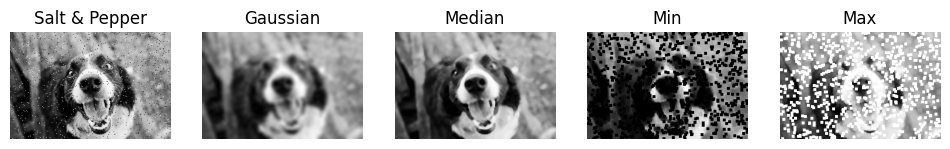

In [82]:
# visualise

plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([
    (sp_noisy, "Salt & Pepper"),
    (gauss, "Gaussian"),
    (median, "Median"),
    (minf, "Min"),
    (maxf, "Max")
]):
    plt.subplot(1,5,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")

plt.show()

#### Step 6: Comparitive Analysis and Kernel size

Every spatial filter has two core controls:
1. Neighborhood size
2. Computation rule (mean, weighted mean, median, min, ma derivative)

In [83]:
# add noise to the image

# Gaussian noise
noise = np.random.normal(0, 20, img.shape).astype(np.int16)
gauss_noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Salt & pepper noise
sp_noisy = add_salt_pepper(img, 0.03)


In [84]:
# compare filters on gaussian noise

b7 = box_filter_cv(gauss_noisy, 7)
g3 = gaussian_filter(gauss_noisy, 11, 3)
m7 = median_filter(gauss_noisy, 7)

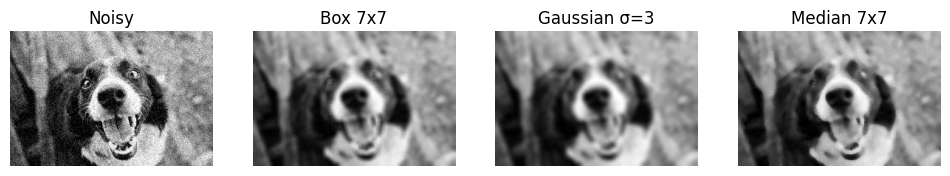

In [85]:
plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([
    (gauss_noisy, "Noisy"),
    (b7, "Box 7x7"),
    (g3, "Gaussian σ=3"),
    (m7, "Median 7x7")
]):
    plt.subplot(1,4,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")
plt.show()

In [86]:
# compare filters on salt and pepper noise

b7 = box_filter_cv(sp_noisy, 7)
g3 = gaussian_filter(sp_noisy, 11, 3)
m7 = median_filter(sp_noisy, 7)

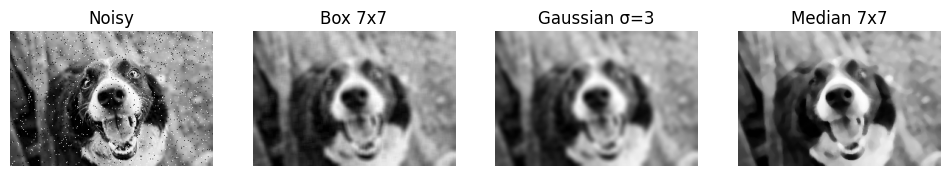

In [87]:
plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([
    (sp_noisy, "Noisy"),
    (b7, "Box 7x7"),
    (g3, "Gaussian σ=3"),
    (m7, "Median 7x7")
]):
    plt.subplot(1,4,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")
plt.show()

In [88]:
# kernel size vs detail preservation

# increasing gaussian (sigma)

g1 = gaussian_filter(gauss_noisy, 5, 1)
g3 = gaussian_filter(gauss_noisy, 11, 3)
g5 = gaussian_filter(gauss_noisy, 21, 5)

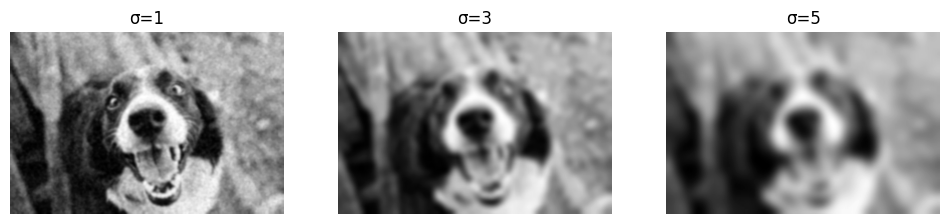

In [89]:
plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([
    (g1, "σ=1"),
    (g3, "σ=3"),
    (g5, "σ=5")
]):
    plt.subplot(1,3,i+1)
    plt.imshow(im, cmap="gray")
    plt.title(t)
    plt.axis("off")
plt.show()